In [85]:
#import des modules nécessaires pour la 1ère partie
import re
import os

#Définition des fonctions
def lirefichier(filename):
    """
    Prend en entrée un chemin vers un fichier avec son nom
    Génère en sortie le contenu du fichier en question
    """
    handle=open(filename, mode="r", encoding="utf-8")
    content=handle.read()
    return content

#Ouverture du fichier choisi comme corpus
climatorealiste=lirefichier("climato-realistes.fr.xml")
#Transfert des données dans un tableau en splitant sur les patterns xml qui reviennent entre les extraits du corpus
tableau=climatorealiste.split("<p xml:id=\"p")

#Nettoyage de toutes les marques xml avec des regex
tableau2=[]
for tab in tableau:
    tab=re.sub(r"\n","",tab)
    tab=re.sub(r"</p>","",tab)
    tab=re.sub(r"<p xml:id=\"p\d+\">","",tab)
    tab=re.sub(r"^\d+\">","",tab)
    tab=re.sub(r"\xa0","",tab)
    tableau2.append(tab)

#Construction d'une copie pour finir le nettoyage (le "pop" décalait tous les indices)
t2=[]
for i in range (len(tableau2)):
    if "<teiHeader>" not in tableau2[i]:
        t2.append(tableau2[i])

#Construction d'un hachage avec 4 arguments/comportements climatosceptiques typiques en clés
#Et les occurrences qui peuvent statistiquement correspondre après recherche par mots-clef et rehex 
#sont en valeur sous forme de tableaux
arguments_typologie={
    "negation_rc":[],#OK
    "attaque_solutions":[],#OK
    "technosolutionnisme":[], #OK
    "attaque_camp_oppose":[] #OK
    }

for t in t2:
    if re.search(r"énergies? renouvelables?|panneaux? solaires?|éoliennes?|photovoltaïque|voitures? électriques?",t,flags=re.I):
        arguments_typologie["attaque_solutions"].append(t)
    if re.search(r'militante?s?|militantismes?|communisme|communistes?|religion|dogme|irrationnels?',t,flags=re.I):
        arguments_typologie["attaque_camp_oppose"].append(t)
    if re.search(r'nucléaire|solutions?|hydrogène|technologies?',t,flags=re.I):
        arguments_typologie["technosolutionnisme"].append(t)
    if re.search(r'réchauffement|pseudo|dérèglement|optimum|température|froid',t,flags=re.I):
        arguments_typologie["negation_rc"].append(t)

#On note que les tableaux en question sont très fournis : 743 documents pour la 1ère recherche par ex.

#Export de ces 4 tableaux dans 4 fichiers séparés
attaque_solutions=open("attaque_solutions.txt", mode="w", encoding="utf-8")
attaque_camp_oppose=open("attaque_camp_oppose.txt", mode="w", encoding="utf-8")
technosolutionnisme=open("technosolutionnisme.txt", mode="w", encoding="utf-8")
negation_rc=open("negation_rc.txt", mode="w", encoding="utf-8")

for i in range (len(arguments_typologie["attaque_solutions"])):
    attaque_solutions.write(f"{i}:{arguments_typologie["attaque_solutions"][i]}\n")

for i in range (len(arguments_typologie["attaque_camp_oppose"])):
    attaque_camp_oppose.write(f"{i}:{arguments_typologie["attaque_camp_oppose"][i]}\n")

for i in range (len(arguments_typologie["technosolutionnisme"])):
    technosolutionnisme.write(f"{i}:{arguments_typologie["technosolutionnisme"][i]}\n")

for i in range (len(arguments_typologie["negation_rc"])):
    negation_rc.write(f"{i}:{arguments_typologie["negation_rc"][i]}\n")


In [86]:
#Ensuite j'ai récupéré les données du fichier "negation_rc.txt". Je les ai c/c dans un autre fichier que j'ai appelé 
#"tri_2_blocs_negation_rc.txt". Il y avait 5198 phrases/paragraphes
#J'ai annoté ce fichier à la main jusqu'à avoir 200 extraits qui niaient l'existence du réchauffement climatique 
#(soit son existence, soit le fait qu'il soit d'origine humaine, soit son intensité, soit le fait que x ou y phénomène soit lié au RC)
# et 200 extraits qui ne le niaient pas (ils pouvaient en revanche s'attaquer aux énergies renouvelables par exemple).
#Quand un extrait n'était pas suffisamment clair pour moi, je le sautais et je passais au suivant. 
#Je les nommais OUI + numéro: extrait ou NON + numéro: extrait pour m'y retrouver, d'où l'algorithme de recherche après

#Export de ma classification dans un tableau
corpus=lirefichier("tri_2_blocs_negation_rc.txt")
t3=corpus.split("\n")
t4=[]
for string in t3:
    if string.startswith("OUI") or string.startswith("NON"):
        t4.append(string)

#Je mets le oui ou le non après l'extrait et pas avant
t5=[]
for t in t4:
    t=[t[3:], t[:3]]
    t5.append(t)

#je supprime les nombres et le ":" qui polluent le corpus 
#et je remplace oui et non par 0 et 1 puisque les classifieurs demandent ce type de labellisation
for t in t5:
    i=0
    while t[0][i]!=":":
        i+=1
    t[0]=t[0][i+1:]
    if t[1]=="OUI":
        t[1]="1"
    else:
        t[1]="0"
    
    
print(t5) #vérification que tout se passe correctement

#Transfert des données nettoyées dans un fichier csv puisque c'est apparemment le format le plus simple pour les classifieurs de texte
fichiertsv=open("corpus.csv", mode="w", encoding="utf-8")
for t in t5:
    fichiertsv.write(f'{t[0]}"\t"{t[1]}"\n"')


[['Aérosols : la réduction des émissions de SO₂ contribue-t-elle au réchauffement climatique ?', '0'], ['Article publié le 01 août 2023 par le service de surveillance de l’atmosphère de Copernicus (CAMS) Traduit par la rédaction Nous avons traité de cette question dans 2 articles publiés sur ce site, ici (Contribution des aérosols au changement climatique observé en Europe) et là (La diminution des aérosols, principale cause du réchauffement hivernal en…', '0'], ['Par Sean Bailly, Journaliste scientifique Article initialement publié le 20 Décembre 2017par Pour la science Desclimatologues ont montré comment des changements de température dans l’hémisphère Nord ont provoqué une rapide aridification du Sahara il y a près de 5\u2009000ans. Au milieu du XIXesiècle, lors d’un trajet entre Tripoli et Tombouctou, l’explorateur allemand Heinrich Barthdécouvrit des…', '1'], ['L’optimum moderne et la crise climatiqueimaginaire Pour les épisodes précédents :épisode 1,épisode 2,épisode 3. parRobert

In [80]:
# Installation des dépendances nécessaires pour que le classifieur fonctionne de bout en bout
%pip install -q transformers datasets evaluate scikit-learn pandas numpy accelerate sentencepiece
%pip install -q matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: C:\Users\lebla\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: C:\Users\lebla\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
#Installation des modules pour la partie classification / machine learning
import numpy as np
import pandas as pd
import torch

# Paramètres
CSV_PATH      = "corpus.csv"         # chemin vers le fichier csv

MODEL_NAME    = "camembert-base"     
OUTPUT_DIR    = "./camembert_climate" #Nom du répertoire de sauvegarde pour le modèle quand il sera entraîné
MAX_LENGTH    = 256 #Choix qui implique plus de temps que 128 mais certains paragraphes du corpus étaient très longs
BATCH_SIZE    = 8                    
NUM_EPOCHS    = 5
LEARNING_RATE = 2e-5
TEST_SIZE     = 0.2                  # 20 % pour la validation et donc avoir des statistiques type matrice de confusion
SEED          = 42
# ──────────────────────────────────────────────────────────────

device ="cpu" #Je n'ai pas de GPU sur mon ordinateur

In [73]:
#Ouverture du fichier csv
handle=open(CSV_PATH, encoding="utf-8")
lines = handle.readlines()

rows = []
for line in lines:
    m = re.match(r'^(.*)\t"([01])"\s*$', line)
    if m:
        texte=m.group(1).strip().strip('"')
        label= int(m.group(2))
        rows.append({"text": texte, "label": label})
print(repr(lines[0]))
print(repr(lines[1]))

df = pd.DataFrame(rows)

# Gestion des erreurs
assert len(df) > 0, "Aucune ligne n'a pu être lue — vérifiez le format du fichier."
assert set(df["label"].unique()).issubset({0, 1}), "Les labels doivent être 0 ou 1 uniquement."

#Premières statistiques et aperçu du corpus
print(f"Nombre d'exemples : {len(df)}")
print(f"\nDistribution des labels :")
print(df["label"].value_counts().rename({0: "non_climatosceptique", 1: "climatosceptique"}).to_string())
print("\nAperçu du corpus :")
df.head()

'Aérosols : la réduction des émissions de SO₂ contribue-t-elle au réchauffement climatique ?"\t"0"\n'
'"Article publié le 01 août 2023 par le service de surveillance de l’atmosphère de Copernicus (CAMS) Traduit par la rédaction Nous avons traité de cette question dans 2 articles publiés sur ce site, ici (Contribution des aérosols au changement climatique observé en Europe) et là (La diminution des aérosols, principale cause du réchauffement hivernal en…"\t"0"\n'
Nombre d'exemples : 402

Distribution des labels :
label
non_climatosceptique    202
climatosceptique        200

Aperçu du corpus :


,text,label
0,Aérosols : la réduction des émissions de SO₂ c...,0
1,Article publié le 01 août 2023 par le service ...,0
2,"Par Sean Bailly, Journaliste scientifique Arti...",1
3,L’optimum moderne et la crise climatiqueimagin...,1
4,la stabilisation relative duclimat Suite de la...,1


In [74]:
#import des modules nécessaires pour cette étape
from sklearn.model_selection import train_test_split
from datasets import Dataset

#On découpe le dataset entre les données d'entraînement et les données de test, en s'arrangeant pour qu'il y ait
#Autant de climatosceptiques que de non climatosceptiques dans les deux jeux de données grâce au stratify=df["label"]
train_df, val_df = train_test_split(
    df, test_size=TEST_SIZE, stratify=df["label"], random_state=SEED
)
#Conversion des formats + remise des numéros des lignes à 0
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
val_dataset   = Dataset.from_pandas(val_df.reset_index(drop=True))

#Print pour savoir le nombre d'extraits dans les 2 jeux 
print(f"Train      : {len(train_df)} exemples")
print(f"Validation : {len(val_df)} exemples")

C:\Users\lebla\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train      : 321 exemples
Validation : 81 exemples


In [75]:
#Import des modules nécessaires pour cette étape, ici le tokenizer de CamemBERT
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH,
    )
#CamemBERT transforme les extraits/phrases/paragraphes en un vecteur de nombre qui a du sens pour lui
train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset   = val_dataset.map(tokenize, batched=True)

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
val_dataset.set_format("torch",   columns=["input_ids", "attention_mask", "label"])

print("Tokenisation terminée ✓")
print(f"Exemple de tokens (premier élément) : {train_dataset[0]['input_ids'][:10]} ...")

C:\Users\lebla\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\lebla\.cache\huggingface\hub\models--camembert-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Map: 100%|██████████| 81/81 [00:00

Tokenisation terminée ✓
Exemple de tokens (premier élément) : tensor([   5,  170,  296, 6215,   28, 1761, 9324, 7474,   13,  447]) ...


In [76]:
#Import des modules nécessaires pour cette étape
from transformers import AutoModelForSequenceClassification

#Charge CamemBERT depuis HuggingFace et lui assigne une tête de classification
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,#2 classes seulement en sortie, climatosceptique ou pas
    id2label={0: "non_climatosceptique", 1: "climatosceptique"},# Correspondance entre les nombres et les labels
    label2id={"non_climatosceptique": 0, "climatosceptique": 1},#Correspondance inverse
)
model.to(device) #Envoie les données sur le processeur cpu

n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Modèle chargé : {MODEL_NAME} ({n_params:.0f}M paramètres) ✓")

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 2763.60it/s]
[transformers] CamembertForSequenceClassification LOAD REPORT from: camembert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Modèle chargé : camembert-base (111M paramètres) ✓


In [78]:
#Import des modules nécessaires pour cette étape
import evaluate
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback

#Choix des métriques d'évaluation du classifieur
accuracy_metric = evaluate.load("accuracy")
f1_metric       = evaluate.load("f1") #= le F-score ou F-mesure

def compute_metrics(eval_pred):
    """
    Cette fonction est appelée automatiquement à la fin de chaque epoch pour évaluer les performances du modèle.
    Entrées : eval_pred qui contient logits (les scores bruts pour chaque phrase) et labels (les vraies réponses)
    Sorties : 2 métriques d'évaluation, l'accuracy, et la précision (F1)
    """
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]
    f1  = f1_metric.compute(predictions=preds, references=labels, average="binary")["f1"]
    return {"accuracy": acc, "f1": f1}

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    weight_decay=0.01, #pour éviter le sur-apprentissage
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True, #charge à la fin la meilleure version du modèle de l'entraînement
    metric_for_best_model="f1", #choix de la précision/F1 comme métrique d'évaluation retenue en priorité
    greater_is_better=True,
    logging_dir=os.path.join(OUTPUT_DIR, "logs"),
    logging_steps=10,
    seed=SEED,
    fp16=(device == "cuda"),
    report_to="none",
)

#assemblage des différents objets
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

#lancement de la boucle complète. Elle a duré 56 minutes.
trainer.train()

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Démarrage de l'entraînement...


C:\Users\lebla\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.680833,0.656149,0.691358,0.691358
2,0.553639,0.559809,0.716049,0.747253
3,0.445411,0.472893,0.802469,0.800000
4,0.326763,0.431834,0.839506,0.835443
5,0.330376,0.425641,0.827160,0.820513


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.82it/s]
C:\Users\lebla\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.01s/it]
C:\Users\lebla\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.45it/s]
C:\Users\lebla\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\utils\dat

TrainOutput(global_step=205, training_loss=0.48726680569532443, metrics={'train_runtime': 3382.7666, 'train_samples_per_second': 0.474, 'train_steps_per_second': 0.061, 'total_flos': 211146621926400.0, 'train_loss': 0.48726680569532443, 'epoch': 5.0})

C:\Users\lebla\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


=== Rapport de classification ===
                      precision    recall  f1-score   support

non_climatosceptique       0.83      0.85      0.84        41
    climatosceptique       0.85      0.82      0.84        40

            accuracy                           0.84        81
           macro avg       0.84      0.84      0.84        81
        weighted avg       0.84      0.84      0.84        81



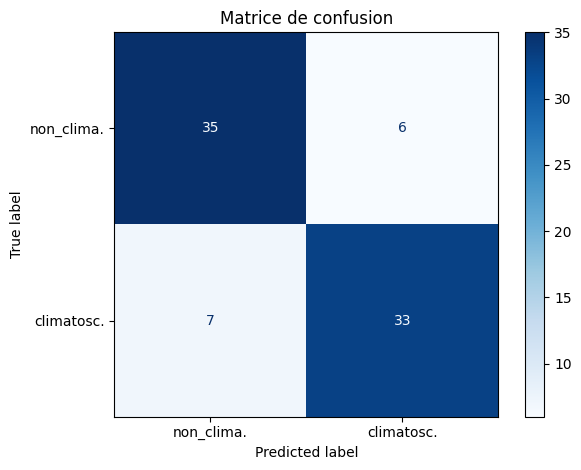

In [81]:
#Import des modules nécessaires pour effectuer une évaluation du modèle
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

preds_output = trainer.predict(val_dataset)
preds  = np.argmax(preds_output.predictions, axis=-1)
labels = preds_output.label_ids

print("=== Rapport de classification ===")
print(classification_report(labels, preds, target_names=["non_climatosceptique", "climatosceptique"]))

cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["non_clima.", "climatosc."])
disp.plot(cmap="Blues")
plt.title("Matrice de confusion")
plt.tight_layout()
plt.show()

In [82]:
#Sauvegarde du modèle qui est maintenant entraîné dans mon répertoire
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"Modèle sauvegardé dans '{OUTPUT_DIR}' ✓")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.40it/s]

Modèle sauvegardé dans './camembert_climate' ✓


In [84]:
#Import des modules pour la partie de tests du modèle sur de nouvelles phrases
import torch.nn.functional as F

def predict(text: str) -> dict:
    """
    Cette fonction permet d'utiliser le modèle qu'on a entraîné avant sur de nouveaux extraits.
    Entrées : une string (l'exemple à tester)
    Sorties : pas de return mais des prints de strings qui donnent la classe prédite et le niveau de confiance
    dans la prédiction
    """
    inputs = tokenizer(
        text,
        return_tensors="pt",
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH,
    ).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(**inputs).logits

    probs  = F.softmax(logits, dim=-1).squeeze().cpu().numpy()
    pred_id = int(probs.argmax())
    label   = model.config.id2label[pred_id]
    icone   = "🔴" if label == "climatosceptique" else "🟢"

    print(f"{icone} [{label.upper()}] — confiance : {probs[pred_id]*100:.1f} %")
    print(f"   P(climatosceptique)     : {probs[1]*100:.1f} %")
    print(f"   P(non_climatosceptique) : {probs[0]*100:.1f} %")
    print()

# Test avec 6 autres éléments du corpus "climato-realistes.fr.xml" qui n'étaient pas dans le fichier csv
# Les 3 premiers extraits ne nient pas le réchauffement climatique selon moi et les 3 suivants le nient
exemples = [
    "Si l’on prend une température moyenne de 36 °C l’après-midi […] avec un air sec, c’est-à-dire un taux d’humidité de 30 %, votre corps va ressentir une température de 40 degrés. Par contre, si l’on prend la même température avec une humidité beaucoup plus élevée, de 60 %, votre corps va ressentir une température de 50 degrés, un inconfort maximal, un véritable danger pour la santé.",
    "C’est ce que suggère la science officielle : Jean Jouzel, ex-vice-président du GIEC, n’en doute pas : «Les vagues de chaleur sont le marqueur du réchauffement planétaire…etclairement le diagnostic est qu’elles vont devenir plus précoces, plus intenses, plus fréquentes».",
    "Températures réelles et températures mesurées",
    "Le réchauffement climatique de 2023 est un événement véritablement exceptionnel dont le catastrophisme ambiant empêche l’analyse scientifique. Je présente des arguments soutenant l’idée que nous sommes confrontés à un événement naturel extraordinaire et extrêmement rare dans l’histoire du climat.",
    "Le 2 décembre 2019 le journal Les Echos publiait un article intitulé « COP 25 : cinq preuves que le dérèglement climatique est déjà là ». Vincent Courtillot, géophysicien membre de l’Académie des sciences et Benoît Rittaud mathématicien, président de l’association des climato réalistes réfutent ici ces cinq allégations.",
    "C’est vrai si l’on se contente de regarder les derniers 150 ans. Mais si l’on regarde les derniers 2000 ans, la période de l’optimum climatique du Moyen-Age (autour du 12ème siècle) était semblable. Plus près de nous, l’enregistrement des températures montre un réchauffement de même amplitude et de même vitesse entre 1910 et 1940 (peu de  CO2 relâché dans l’atmosphère) et entre 1970 et 2000 (beaucoup plus de  CO2 ). Et depuis 20 ans, alors qu’il n’y a jamais eu autant de  CO2 relâché dans l’atmosphère par l’humanité, la température moyenne est restée stable, contrairement aux prédictions de la plupart des modèles. Enfin les températures autour de 2016 sont affectées par un événement chaud dit El Nino qui est météorologique et non climatique. Rien qui prouve que le dérèglement climatique soit déjà là.",
]

for texte in exemples:
    print(f'Texte : "{texte}"')
    predict(texte)

#Une erreur en regardant la sortie avec la phrase 2 qui est considérée comme climatosceptique
#Peut-être est-ce à cause du syntagme "science officielle" qui a été utilisé ailleurs dans le corpus pour mettre en doute le RC
#Les autres sont bien classées

Texte : "Si l’on prend une température moyenne de 36 °C l’après-midi […] avec un air sec, c’est-à-dire un taux d’humidité de 30 %, votre corps va ressentir une température de 40 degrés. Par contre, si l’on prend la même température avec une humidité beaucoup plus élevée, de 60 %, votre corps va ressentir une température de 50 degrés, un inconfort maximal, un véritable danger pour la santé."
🟢 [NON_CLIMATOSCEPTIQUE] — confiance : 77.3 %
   P(climatosceptique)     : 22.7 %
   P(non_climatosceptique) : 77.3 %

Texte : "C’est ce que suggère la science officielle : Jean Jouzel, ex-vice-président du GIEC, n’en doute pas : «Les vagues de chaleur sont le marqueur du réchauffement planétaire…etclairement le diagnostic est qu’elles vont devenir plus précoces, plus intenses, plus fréquentes»."
🔴 [CLIMATOSCEPTIQUE] — confiance : 80.4 %
   P(climatosceptique)     : 80.4 %
   P(non_climatosceptique) : 19.6 %

Texte : "Températures réelles et températures mesurées"
🟢 [NON_CLIMATOSCEPTIQUE] — confianc